# Step 1: Restoration and Edge Map

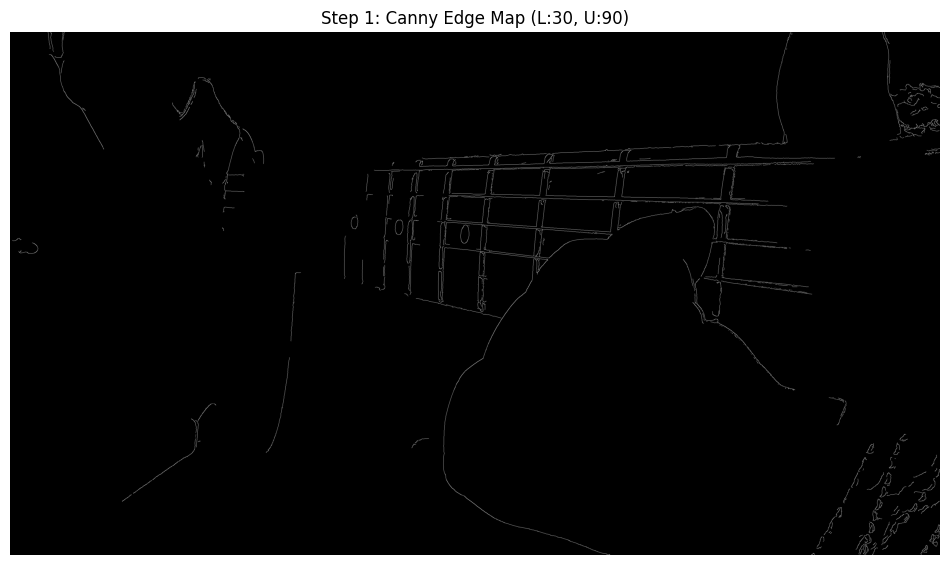

--- Step 1 Successful: Edge map generated! ---


In [9]:
import cv2
import matplotlib.pyplot as plt
import os

# 1. Define the path to one of the processed frames from Day 1
# Make sure the filename matches exactly what is in your processed_frames folder!
processed_frame_path = "../data/processed_frames/A_01_seg1_A.jpg"

if not os.path.exists(processed_frame_path):
    print(f"Error: The file {processed_frame_path} does not exist. Check the name!")
else:
    # 2. Load the pre-processed image (it's already grayscale, equalized, and blurred)
    # We use cv2.IMREAD_GRAYSCALE to ensure it's loaded as a single-channel image
    processed_image = cv2.imread(processed_frame_path, cv2.IMREAD_GRAYSCALE)
    
    # 3. Apply Canny Edge Detection using our validated thresholds (30, 90)
    LOWER_THRESH = 30
    UPPER_THRESH = 90
    edges = cv2.Canny(processed_image, LOWER_THRESH, UPPER_THRESH)
    
    # 4. Display the result to confirm everything is working
    plt.figure(figsize=(12, 7))
    plt.imshow(edges, cmap='gray')
    plt.title(f'Step 1: Canny Edge Map (L:{LOWER_THRESH}, U:{UPPER_THRESH})')
    plt.axis('off')
    plt.show()
    
    print("--- Step 1 Successful: Edge map generated! ---")

# Step 2: MediaPipe landmarks

## First attempt [X]

Success: Found 1 hand(s)!


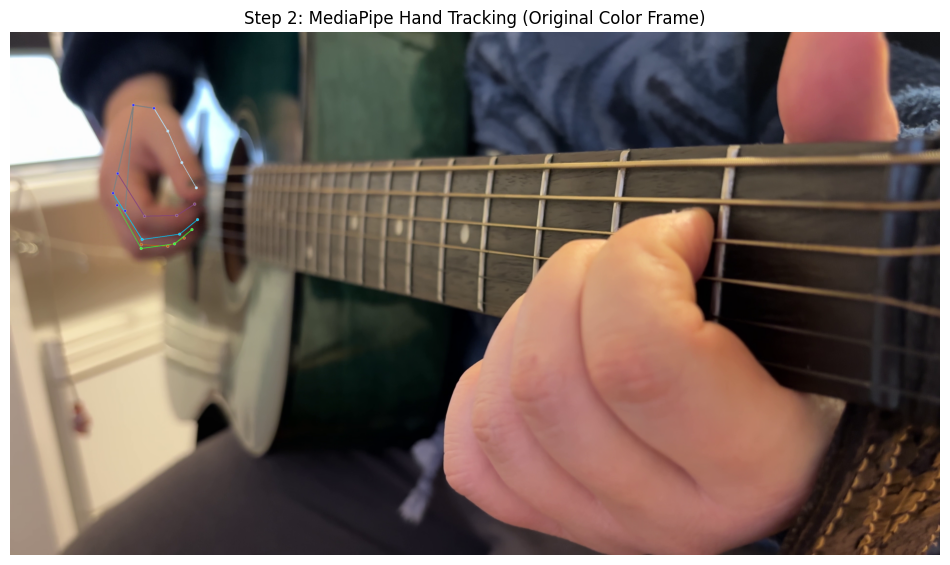

In [3]:
import cv2
import mediapipe as mp
import matplotlib.pyplot as plt

# 1. Initialize MediaPipe Hands
mp_hands = mp.solutions.hands
mp_drawing = mp.solutions.drawing_utils
mp_drawing_styles = mp.solutions.drawing_styles

# Initialize the Hands model with lower strictness and higher complexity
hands = mp_hands.Hands(
    static_image_mode=True, 
    max_num_hands=2, 
    min_detection_confidence=0.1,  #confidence at 10%
    model_complexity=1            #more precise model
)

# 2. Extract the ORIGINAL color frame from the video (same timestamp as Day 1)
video_path = "../data/raw_videos/A_01.mp4"
target_time_sec = 6.210

cap = cv2.VideoCapture(video_path)
cap.set(cv2.CAP_PROP_POS_MSEC, target_time_sec * 1000.0)
success, original_frame = cap.read()
cap.release()

if not success:
    print(f"Error: Could not extract original frame at {target_time_sec}s")
else:
    # 3. Convert from BGR (OpenCV format) to RGB (MediaPipe format)
    frame_rgb = cv2.cvtColor(original_frame, cv2.COLOR_BGR2RGB)
    
    # 4. Process the image to find hand landmarks
    results = hands.process(frame_rgb)
    
    # 5. Draw the landmarks on a copy of the original image for visualization
    annotated_image = frame_rgb.copy()
    
    if results.multi_hand_landmarks:
        print(f"Success: Found {len(results.multi_hand_landmarks)} hand(s)!")
        
        for hand_landmarks in results.multi_hand_landmarks:
            # Draw the skeletal connections
            mp_drawing.draw_landmarks(
                annotated_image,
                hand_landmarks,
                mp_hands.HAND_CONNECTIONS,
                mp_drawing_styles.get_default_hand_landmarks_style(),
                mp_drawing_styles.get_default_hand_connections_style())
    else:
        print("Warning: No hands detected by MediaPipe.")
        
    # 6. Display the result
    plt.figure(figsize=(12, 7))
    plt.imshow(annotated_image)
    plt.title('Step 2: MediaPipe Hand Tracking (Original Color Frame)')
    plt.axis('off')
    plt.show()

# Close the MediaPipe instance to free memory
hands.close()

## Second attempt (cropping)

Found hand on fretboard.


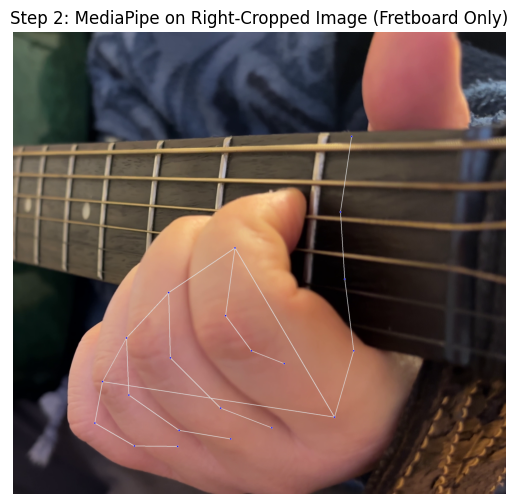

In [18]:
import cv2
import mediapipe as mp
import matplotlib.pyplot as plt

mp_hands = mp.solutions.hands
mp_drawing = mp.solutions.drawing_utils

hands = mp_hands.Hands(static_image_mode=True, max_num_hands=1, min_detection_confidence=0.1, model_complexity=1)

# frame extraction
video_path = "../data/raw_videos/A_01.mp4"
target_time_sec = 6.210
cap = cv2.VideoCapture(video_path)
cap.set(cv2.CAP_PROP_POS_MSEC, target_time_sec * 1000.0)
success, original_frame = cap.read()
cap.release()

if success:
    frame_rgb = cv2.cvtColor(original_frame, cv2.COLOR_BGR2RGB)
    
    # Discard 40% of left side of image and keep the right side (fretboard)
    height, width, _ = frame_rgb.shape
    right_half_img = frame_rgb[:, int(width * 0.40):]
    
    results = hands.process(right_half_img)
    annotated_image = right_half_img.copy()
    
    if results.multi_hand_landmarks:
        print("Found hand on fretboard.")
        for hand_landmarks in results.multi_hand_landmarks:
            mp_drawing.draw_landmarks(annotated_image, hand_landmarks, mp_hands.HAND_CONNECTIONS)
    else:
        print("Hand is too occluded.")
        
    plt.figure(figsize=(10, 6))
    plt.imshow(annotated_image)
    plt.title('Step 2: MediaPipe on Right-Cropped Image (Fretboard Only)')
    plt.axis('off')
    plt.show()

hands.close()

# Step 3: Isolating Region of Interest 

Calculated Bounding Box: X(352-1622), Y(458-1967)


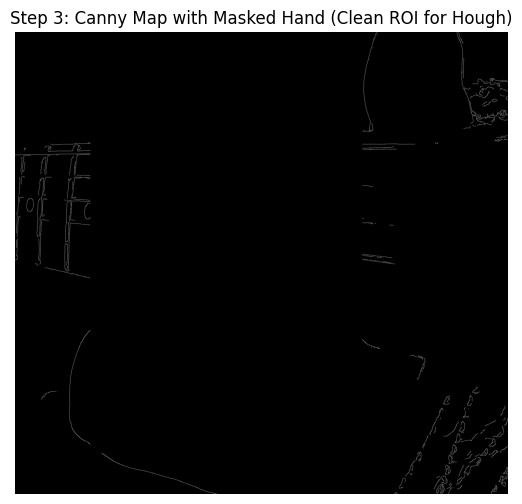

In [11]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

# 1. Retrieve the original Canny image (from Step 1) and crop it 
# exactly as we did with the color image, so they match perfectly.
height, width = edges.shape
edges_cropped = edges[:, int(width * 0.40):].copy()

# Ensure MediaPipe found the landmarks in the previous step
if results.multi_hand_landmarks:
    # We only take the first detected hand (the one on the fretboard)
    hand_landmarks = results.multi_hand_landmarks[0]
    
    # 2. Calculate the bounding box boundaries for the hand (Min and Max for X and Y)
    h, w = edges_cropped.shape
    x_coords = [landmark.x for landmark in hand_landmarks.landmark]
    y_coords = [landmark.y for landmark in hand_landmarks.landmark]
    
    x_min, x_max = int(min(x_coords) * w), int(max(x_coords) * w)
    y_min, y_max = int(min(y_coords) * h), int(max(y_coords) * h)
    
    # 3. Add padding (safety margin) to fully cover the hand and its edges
    padding_x = 30
    padding_y = 30
    x_min = max(0, x_min - padding_x)
    x_max = min(w, x_max + padding_x)
    y_min = max(0, y_min - padding_y)
    y_max = min(h, y_max + padding_y)
    
    # 4. Create the Mask: draw a solid BLACK rectangle on the Canny image
    # to erase all the noise generated by the fingers and skin
    cv2.rectangle(edges_cropped, (x_min, y_min), (x_max, y_max), (0, 0, 0), -1)
    
    print(f"Calculated Bounding Box: X({x_min}-{x_max}), Y({y_min}-{y_max})")
else:
    print("Warning: No hand landmarks available to create the mask.")

# 5. Display the result
plt.figure(figsize=(10, 6))
plt.imshow(edges_cropped, cmap='gray')
plt.title('Step 3: Canny Map with Masked Hand (Clean ROI for Hough)')
plt.axis('off')
plt.show()

## ROI second attempt

Mask applied on full image at X(1898-3148), Y(468-1957)


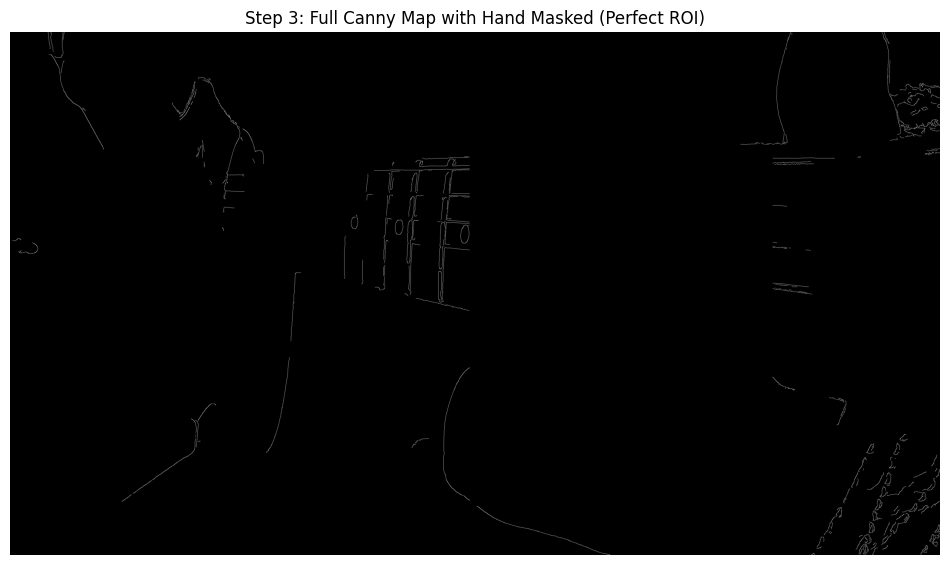

In [12]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

# 1. We start from a fresh copy of the FULL original Canny map (from Step 1)
# We do NOT crop it this time, we want to keep the beautiful strings on the left!
full_edges_masked = edges.copy()
height, width = full_edges_masked.shape

# This is the offset we used to crop the image for MediaPipe in Step 2
crop_offset_x = int(width * 0.40)

if results.multi_hand_landmarks:
    hand_landmarks = results.multi_hand_landmarks[0]
    
    # 2. Calculate bounding box. Note: MediaPipe returns normalized coordinates (0.0 to 1.0).
    # We must multiply them by the width of the CROPPED image we passed to it.
    cropped_width = width - crop_offset_x
    
    x_coords = [landmark.x for landmark in hand_landmarks.landmark]
    y_coords = [landmark.y for landmark in hand_landmarks.landmark]
    
    x_min_crop = int(min(x_coords) * cropped_width)
    x_max_crop = int(max(x_coords) * cropped_width)
    y_min = int(min(y_coords) * height)
    y_max = int(max(y_coords) * height)
    
    # 3. Add a smaller padding (e.g., 20 pixels instead of 30)
    padding = 20
    x_min_crop = max(0, x_min_crop - padding)
    x_max_crop = min(cropped_width, x_max_crop + padding)
    y_min = max(0, y_min - padding)
    y_max = min(height, y_max + padding)
    
    # 4. THE MAGIC TRICK: Shift the X coordinates back to the FULL image space
    x_min_full = x_min_crop + crop_offset_x
    x_max_full = x_max_crop + crop_offset_x
    
    # 5. Draw the solid BLACK rectangle on the FULL Canny image
    cv2.rectangle(full_edges_masked, (x_min_full, y_min), (x_max_full, y_max), (0, 0, 0), -1)
    
    print(f"Mask applied on full image at X({x_min_full}-{x_max_full}), Y({y_min}-{y_max})")
else:
    print("Warning: No hand landmarks available to create the mask.")

# 6. Display the final clean ROI
plt.figure(figsize=(12, 7))
plt.imshow(full_edges_masked, cmap='gray')
plt.title('Step 3: Full Canny Map with Hand Masked (Perfect ROI)')
plt.axis('off')
plt.show()

Surgery successful: Hand masked at X:1913-3133, Y:483-1942


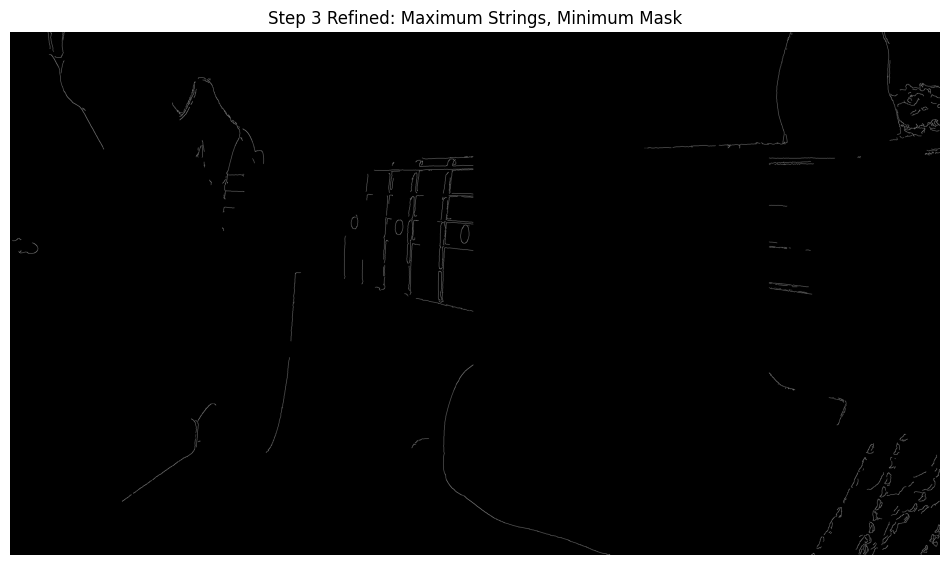

In [23]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

# 1. Start with a fresh copy of the FULL Canny image from Step 1
# This ensures we have ALL the strings back
full_edges_refined = edges.copy()
height, width = full_edges_refined.shape

# 2. This must match the offset you used in Step 2 (40% of width)
crop_offset_x = int(width * 0.40)
cropped_width = width - crop_offset_x

if results.multi_hand_landmarks:
    hand_landmarks = results.multi_hand_landmarks[0]
    
    # Extract coordinates and scale them to the FULL image size
    # x is relative to the cropped image, so we add the offset
    x_coords = [int(l.x * cropped_width) + crop_offset_x for l in hand_landmarks.landmark]
    y_coords = [int(l.y * height) for l in hand_landmarks.landmark]
    
    # Find the boundaries of the hand
    x_min, x_max = min(x_coords), max(x_coords)
    y_min, y_max = min(y_coords), max(y_coords)
    
    # 3. Apply a VERY TIGHT padding (only 5 pixels)
    # This prevents the "giant black block" effect
    padding = 5
    x_min = max(0, x_min - padding)
    x_max = min(width, x_max + padding)
    y_min = max(0, y_min - padding)
    y_max = min(height, y_max + padding)
    
    # 4. Draw the black rectangle ONLY on the hand
    cv2.rectangle(full_edges_refined, (x_min, y_min), (x_max, y_max), (0, 0, 0), -1)
    print(f"Surgery successful: Hand masked at X:{x_min}-{x_max}, Y:{y_min}-{y_max}")
else:
    print("Warning: No hand detected to mask.")

# 5. Show the result - You should see ALL strings and just a small black box on the hand
plt.figure(figsize=(12, 7))
plt.imshow(full_edges_refined, cmap='gray')
plt.title('Step 3 Refined: Maximum Strings, Minimum Mask')
plt.axis('off')
plt.show()

# Step 4: Probabilistic Hough Transform 

Extraction Complete: Found 42 string segments and 57 fret segments.


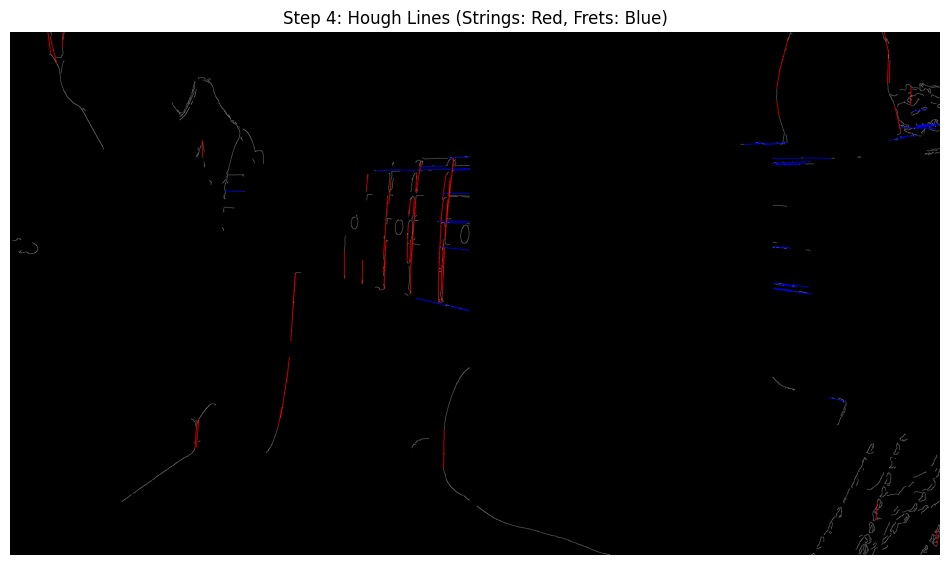

In [13]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Create a color copy of our masked Canny image to draw colored lines on it
# (Since the original is grayscale/binary, we need 3 channels for RGB colors)
hough_img = cv2.cvtColor(full_edges_masked, cv2.COLOR_GRAY2BGR)

# 2. Apply Probabilistic Hough Transform
# Parameters to tweak if it fails:
# - threshold: minimum number of votes (intersections) to be considered a line
# - minLineLength: minimum length of a line segment (pixels)
# - maxLineGap: maximum allowed gap between points on the same line to link them! (The "bridge")
lines = cv2.HoughLinesP(
    full_edges_masked, 
    rho=1, 
    theta=np.pi/180, 
    threshold=40, 
    minLineLength=60, 
    maxLineGap=25
)

strings_count = 0
frets_count = 0

if lines is not None:
    for line in lines:
        x1, y1, x2, y2 = line[0]
        
        # 3. Calculate the angle of the line to classify it as String (Horizontal) or Fret (Vertical)
        # We avoid division by zero using a small epsilon
        angle = np.abs(np.degrees(np.arctan2(y2 - y1, x2 - x1 + 1e-6)))
        
        # If the line is mostly horizontal (angle close to 0 or 180) -> STRING
        if angle < 15 or angle > 165:
            cv2.line(hough_img, (x1, y1), (x2, y2), (255, 0, 0), 2) # RED for strings
            strings_count += 1
            
        # If the line is mostly vertical (angle close to 90) -> FRET
        elif 75 < angle < 105:
            cv2.line(hough_img, (x1, y1), (x2, y2), (0, 0, 255), 2) # BLUE for frets
            frets_count += 1
            
    print(f"Extraction Complete: Found {strings_count} string segments and {frets_count} fret segments.")
else:
    print("Failure: Hough Transform could not find any clear lines.")

# 4. Display the reality check
plt.figure(figsize=(12, 7))
plt.imshow(cv2.cvtColor(hough_img, cv2.COLOR_BGR2RGB))
plt.title(f'Step 4: Hough Lines (Strings: Red, Frets: Blue)')
plt.axis('off')
plt.show()

## Step 4: second attempt 

Extraction Complete: Found 52 horizontal segments and 74 vertical segments.


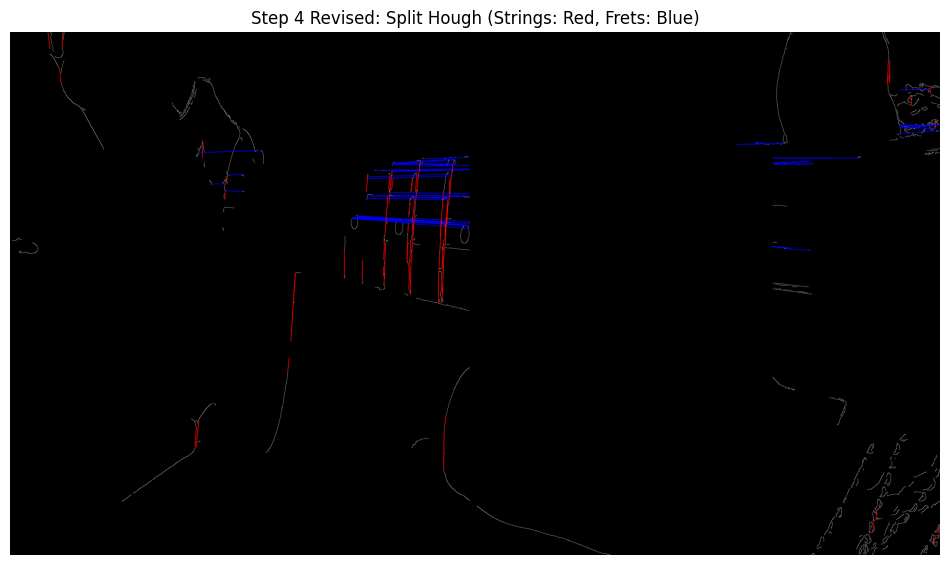

In [14]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Create color canvas
hough_img = cv2.cvtColor(full_edges_masked, cv2.COLOR_GRAY2BGR)

# ============================================
# PASS 1: STRING HUNTERS (Horizontal, Aggressive)
# ============================================
# We need a HUGE gap allowance to bridge the masked hand area
lines_horizontal = cv2.HoughLinesP(
    full_edges_masked, 
    rho=1, 
    theta=np.pi/180, 
    threshold=30,      # Lower threshold to pick up faint string bits
    minLineLength=50,  # Strings must be somewhat long segments initially
    maxLineGap=150     # HUGE GAP: JUMP ACROSS THE BLACK HOLE!
)

strings_count = 0
if lines_horizontal is not None:
    for line in lines_horizontal:
        x1, y1, x2, y2 = line[0]
        angle = np.abs(np.degrees(np.arctan2(y2 - y1, x2 - x1 + 1e-6)))
        
        # STRICT HORIZONTAL FILTER: Only angles very close to 0 or 180 (+/- 5 degrees)
        if angle < 5 or angle > 175:
            # DRAW RED FOR STRINGS (Corrected color logic)
            cv2.line(hough_img, (x1, y1), (x2, y2), (255, 0, 0), 2) 
            strings_count += 1

# ============================================
# PASS 2: FRET HUNTERS (Vertical, Conservative)
# ============================================
lines_vertical = cv2.HoughLinesP(
    full_edges_masked, 
    rho=1, 
    theta=np.pi/180, 
    threshold=40,      # Higher threshold: frets are strong solid lines
    minLineLength=30,  # Frets are shorter than strings
    maxLineGap=20      # Small gap: frets shouldn't have big breaks
)

frets_count = 0
if lines_vertical is not None:
    for line in lines_vertical:
        x1, y1, x2, y2 = line[0]
        angle = np.abs(np.degrees(np.arctan2(y2 - y1, x2 - x1 + 1e-6)))
        
        # STRICT VERTICAL FILTER: Only angles very close to 90 (+/- 8 degrees)
        # This should eliminate the guitar body curves
        if 82 < angle < 98:
            # DRAW BLUE FOR FRETS (Corrected color logic)
            cv2.line(hough_img, (x1, y1), (x2, y2), (0, 0, 255), 2)
            frets_count += 1

print(f"Extraction Complete: Found {strings_count} horizontal segments and {frets_count} vertical segments.")

# 4. Display the new reality check
plt.figure(figsize=(12, 7))
plt.imshow(cv2.cvtColor(hough_img, cv2.COLOR_BGR2RGB))
plt.title(f'Step 4 Revised: Split Hough (Strings: Red, Frets: Blue)')
plt.axis('off')
plt.show()

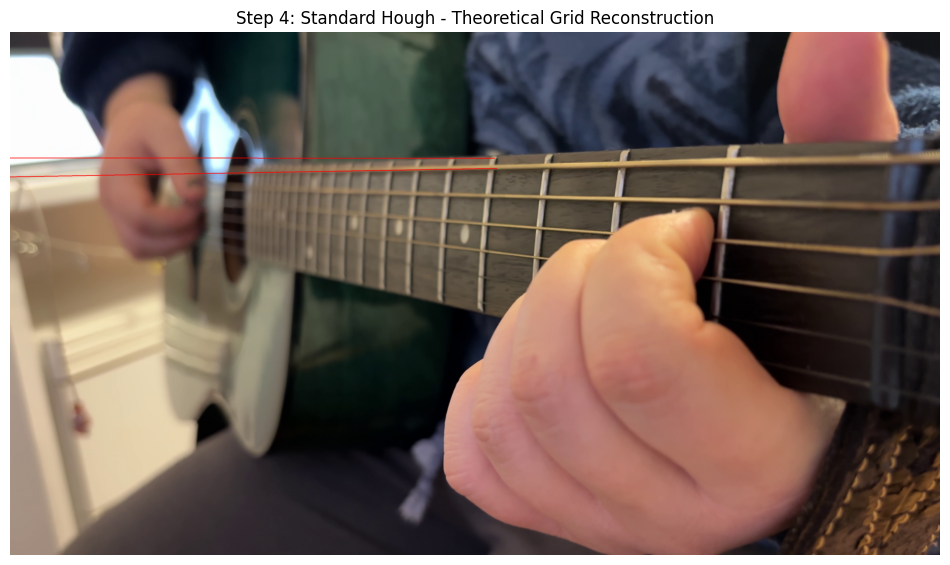

In [22]:
# Create a fresh canvas from the ORIGINAL color frame for better visualization
hough_grid_img = original_frame.copy()

# Standard Hough Transform
# rho=1, theta=pi/180, threshold=150 (only the strongest lines)
lines_std = cv2.HoughLines(full_edges_smart, 1, np.pi / 180, 150)

if lines_std is not None:
    for line in lines_std:
        rho, theta = line[0]
        a = np.cos(theta)
        b = np.sin(theta)
        x0 = a * rho
        y0 = b * rho
        
        # Convert polar coordinates to Cartesian for drawing infinite lines
        x1 = int(x0 + 2000 * (-b))
        y1 = int(y0 + 2000 * (a))
        x2 = int(x0 - 2000 * (-b))
        y2 = int(y0 - 2000 * (a))
        
        angle = np.degrees(theta)
        
        # Filter for STRINGS (theta should be near 90 degrees for horizontal lines in this coordinate system)
        if 85 < angle < 95:
            cv2.line(hough_grid_img, (x1, y1), (x2, y2), (0, 0, 255), 2) # RED Strings
        
        # Filter for FRETS (theta should be near 0 or 180 degrees for vertical lines)
        if angle < 5 or angle > 175:
            cv2.line(hough_grid_img, (255, 0, 0), (x1, y1), (x2, y2), 2) # BLUE Frets

plt.figure(figsize=(12, 7))
plt.imshow(cv2.cvtColor(hough_grid_img, cv2.COLOR_BGR2RGB))
plt.title('Step 4: Standard Hough - Theoretical Grid Reconstruction')
plt.axis('off')
plt.show()

In [ ]:
# Create a canvas to draw our findings
final_viz = cv2.cvtColor(full_edges_refined, cv2.COLOR_GRAY2BGR)

# Apply Probabilistic Hough with balanced parameters
lines = cv2.HoughLinesP(
    full_edges_refined, 
    rho=1, 
    theta=np.pi/180, 
    threshold=40,       # Number of votes to accept a line
    minLineLength=60,   # Minimum length of a string segment
    maxLineGap=100      # Distance to jump over the hand mask
)

strings_count = 0
frets_count = 0

if lines is not None:
    for line in lines:
        x1, y1, x2, y2 = line[0]
        # Calculate angle
        angle = np.abs(np.degrees(np.arctan2(y2 - y1, x2 - x1 + 1e-6)))
        
        # 1. STRINGS (Horizontal: 0° or 180°)
        if angle < 8 or angle > 172:
            cv2.line(final_viz, (x1, y1), (x2, y2), (255, 0, 0), 2) # RED
            strings_count += 1
            
        # 2. FRETS (Vertical: 90°)
        elif 80 < angle < 100:
            cv2.line(final_viz, (x1, y1), (x2, y2), (0, 0, 255), 2) # BLUE
            frets_count += 1

print(f"Success! Found {strings_count} String segments and {frets_count} Fret segments.")

plt.figure(figsize=(12, 7))
plt.imshow(cv2.cvtColor(final_viz, cv2.COLOR_BGR2RGB))
plt.title('Step 4: Strings (Red) and Frets (Blue) - Rebuilt')
plt.axis('off')
plt.show()